In [8]:
# Model parameters for interest rates, exchange rate, and stock price
r_A = 0.0361  # Initial interest rate for US
kappa_A = 0.0700903059693999  # Mean-reversion speed for r_A
theta_A = 0.07303214899396632  # Long-term mean for r_A
sigma_A = 0.00496616586636715  # Volatility of r_A

r_B = 0.00855  # Initial interest rate for country Japan
kappa_B = -1.7201871884675866  # Mean-reversion speed for r_B
theta_B = -8.569540223134506e-05  # Long-term mean for r_B
sigma_B = 0.0052880773038487  # Volatility of r_B

sigma_Y = 0.005675218564377177  # Volatility of exchange rate
sigma_S = 0.013847288840989729  # Volatility of stock price

# Initial conditions and simulation parameters
Y0 = 160.233994  # Initial exchange rate
S0 = 100  # Initial stock price
T = 0.25  # Time to maturity in years
N = 10000  # Number of paths
M = 252  # Number of time steps (daily steps for a year)

# Payoff structure parameters
Strike_0 = 0  # Upper strike level
Strike_1 = -0.05  # Lower strike level
max_conp = 0.5  # Maximum payoff multiplier
principal = 1000  # Principal amount

In [9]:
import numpy as np  # For multivariate normal distribution
import matplotlib.pyplot as plt  # For data visualization
def monte_carlo_simulation(T, N, M, sigma_Y, Y0, r_A, r_B, sigma_S, S0,
                           kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B):
    dt = T / M  # Time step (length of each simulation step)
    Z = np.random.multivariate_normal(mean=np.zeros(4), cov=np.eye(4), size=N)  # Generate correlated random shocks

    # Function to simulate a single path
    def simulate_path():
        Y = Y0  # Initialize exchange rate
        S = S0  # Initialize stock price
        r_A_t = r_A  # Initialize interest rate for country A
        r_B_t = r_B  # Initialize interest rate for country B

        # Simulate over M time steps
        for t in range(M):
            dW = np.sqrt(dt) * Z[np.random.choice(N, 4, replace=True)]  # Random shocks scaled by time step
            r_A_t = r_A_t + kappa_A * (theta_A - r_A_t) * dt + sigma_A * dW[0, 0]  # Update r_A_t
            r_B_t = r_B_t + kappa_B * (theta_B - r_B_t) * dt + sigma_B * dW[1, 1]  # Update r_B_t
            Y = Y + (r_B_t - r_A_t) * Y * dt + sigma_Y * Y * dW[2, 2]  # Update exchange rate
            S = S + r_A_t * S * dt + sigma_S * S * dW[3, 3]  # Update stock price

        return [r_A_t, Y, S]  # Return final values of interest rates, exchange rate, and stock price

    results = np.array([simulate_path() for _ in range(N)])  # Simulate N paths
    return results.T  # Transpose to match R's replicate output (3 x N)

In [10]:
def calculate_payoff(dif, Strike_0, Strike_1, max_conp, principal):
    def payoff_single(x):
        if x >= Strike_0:
            return 0  # No loss if return is above Strike_0
        elif x > Strike_1:
            return -((Strike_0 - x) / (Strike_0 - Strike_1)) * max_conp * x * principal  # Scaled loss
        else:
            return -max_conp * x * principal  # Maximum loss
    return np.array([payoff_single(x) for x in dif])

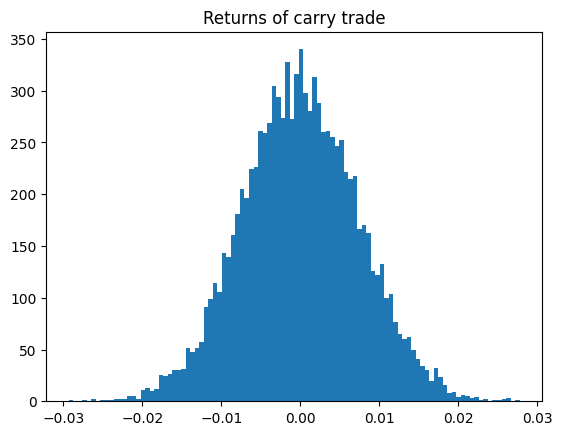

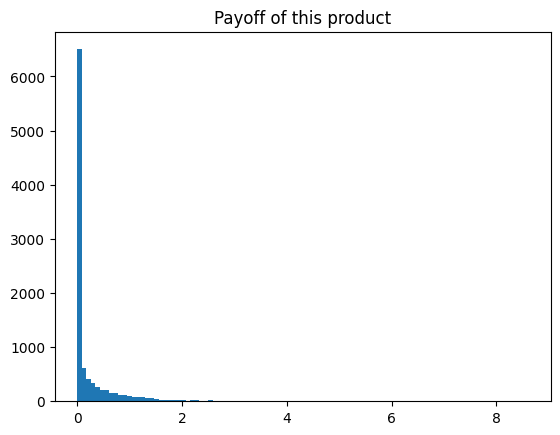

Mean Payoffs: 0.2681712047637977


In [17]:
# Simulate paths and calculate returns
paths = monte_carlo_simulation(T, N, M, sigma_Y, Y0, r_A, r_B, sigma_S, S0,
                               kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
returns = (np.log(paths[2, :]) + np.log(paths[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T  # Calculate returns
plt.hist(returns, bins=100); plt.title("Returns of carry trade"); plt.show()  # Visualize the distribution of returns

# Calculate payoffs and visualize the payoff distribution
payoffs = calculate_payoff(returns, Strike_0, Strike_1, max_conp, principal)
plt.hist(payoffs, bins=100); plt.title("Payoff of this product"); plt.show()
mean_payoffs = np.mean(payoffs)  # Calculate mean payoff
print("Mean Payoffs:", mean_payoffs)


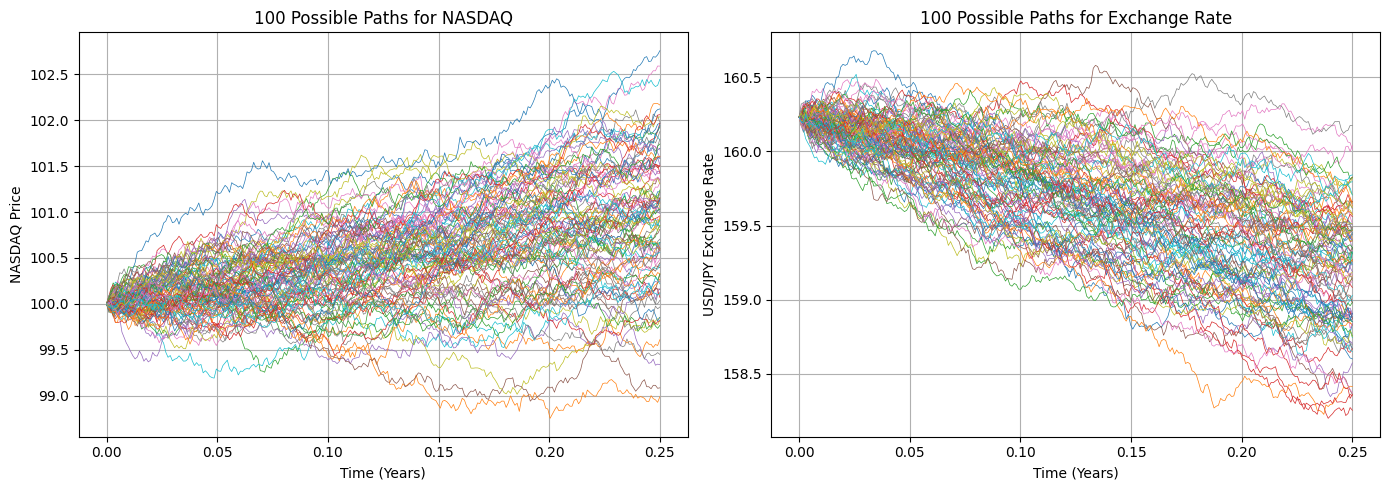

In [8]:
# Simulate 100 paths and record full trajectories
dt = T / M
n_paths = 100
time_axis = np.linspace(0, T, M + 1)

S_paths = np.zeros((n_paths, M + 1))
Y_paths = np.zeros((n_paths, M + 1))

for i in range(n_paths):
    Z = np.random.multivariate_normal(mean=np.zeros(4), cov=np.eye(4), size=M)
    S = S0
    Y = Y0
    r_A_t = r_A
    r_B_t = r_B
    S_paths[i, 0] = S
    Y_paths[i, 0] = Y
    for t in range(M):
        dW = np.sqrt(dt) * Z[t]
        r_A_t = r_A_t + kappa_A * (theta_A - r_A_t) * dt + sigma_A * dW[0]
        r_B_t = r_B_t + kappa_B * (theta_B - r_B_t) * dt + sigma_B * dW[1]
        Y = Y + (r_B_t - r_A_t) * Y * dt + sigma_Y * Y * dW[2]
        S = S + r_A_t * S * dt + sigma_S * S * dW[3]
        S_paths[i, t + 1] = S
        Y_paths[i, t + 1] = Y

# Plot 100 Possible Paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(n_paths):
    axes[0].plot(time_axis, S_paths[i], alpha=1, linewidth=0.5)
axes[0].set_xlabel("Time (Years)")
axes[0].set_ylabel("NASDAQ Price")
axes[0].set_title("100 Possible Paths for NASDAQ")
axes[0].grid(True)

for i in range(n_paths):
    axes[1].plot(time_axis, Y_paths[i], alpha=1, linewidth=0.5)
axes[1].set_xlabel("Time (Years)")
axes[1].set_ylabel("USD/JPY Exchange Rate")
axes[1].set_title("100 Possible Paths for Exchange Rate")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Bump stock price to calculate sensitivity (Delta for stock price)
h = 0.001  # Small bump percentage

# Positive bump in stock price
paths_stock_pos = monte_carlo_simulation(T, N, M, sigma_Y, Y0, r_A, r_B, sigma_S, S0 + 0.5 * h * S0,
                                         kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
returns_stock_pos = (np.log(paths_stock_pos[2, :]) + np.log(paths_stock_pos[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T
payoffs_stock_pos = calculate_payoff(returns_stock_pos, Strike_0, Strike_1, max_conp, principal)

# Negative bump in stock price
paths_stock_neg = monte_carlo_simulation(T, N, M, sigma_Y, Y0, r_A, r_B, sigma_S, S0 - 0.5 * h * S0,
                                         kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
returns_stock_neg = (np.log(paths_stock_neg[2, :]) + np.log(paths_stock_neg[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T
payoffs_stock_neg = calculate_payoff(returns_stock_neg, Strike_0, Strike_1, max_conp, principal)

# Calculate Delta for stock price
delta_stock = (np.mean(payoffs_stock_pos) - np.mean(payoffs_stock_neg)) / (h * S0)
print("Delta Stock:", delta_stock)

# Bump exchange rate to calculate sensitivity (Delta for exchange rate)
paths_fx_pos = monte_carlo_simulation(T, N, M, sigma_Y, Y0 + 0.5 * h * Y0, r_A, r_B, sigma_S, S0,
                                      kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
returns_fx_pos = (np.log(paths_fx_pos[2, :]) + np.log(paths_fx_pos[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T
payoffs_fx_pos = calculate_payoff(returns_fx_pos, Strike_0, Strike_1, max_conp, principal)

paths_fx_neg = monte_carlo_simulation(T, N, M, sigma_Y, Y0 - 0.5 * h * Y0, r_A, r_B, sigma_S, S0,
                                      kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
returns_fx_neg = (np.log(paths_fx_neg[2, :]) + np.log(paths_fx_neg[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T
payoffs_fx_neg = calculate_payoff(returns_fx_neg, Strike_0, Strike_1, max_conp, principal)

# Calculate Delta for exchange rate
delta_fx = (np.mean(payoffs_fx_pos) - np.mean(payoffs_fx_neg)) / (h * Y0)
print("Delta FX:", delta_fx)

Delta Stock: 3.742316110118704
Delta FX: 0.26196545399313015


In [ ]:
# # Calculate Delta for a range of stock prices and exchange rates
# h = 0.001

# S0_range = np.linspace(S0 * 0.8, S0 * 1.2, 20)
# Y0_range = np.linspace(Y0 * 0.8, Y0 * 1.2, 20)

# delta_stock_list = []
# delta_fx_list = []

# # Delta as a function of stock price
# for s in S0_range:
#     paths_pos = monte_carlo_simulation(T, N, M, sigma_Y, Y0, r_A, r_B, sigma_S, s + 0.5 * h * s,
#                                        kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
#     returns_pos = (np.log(paths_pos[2, :]) + np.log(paths_pos[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T
#     payoffs_pos = calculate_payoff(returns_pos, Strike_0, Strike_1, max_conp, principal)

#     paths_neg = monte_carlo_simulation(T, N, M, sigma_Y, Y0, r_A, r_B, sigma_S, s - 0.5 * h * s,
#                                        kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
#     returns_neg = (np.log(paths_neg[2, :]) + np.log(paths_neg[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T
#     payoffs_neg = calculate_payoff(returns_neg, Strike_0, Strike_1, max_conp, principal)

#     delta_stock_list.append((np.mean(payoffs_pos) - np.mean(payoffs_neg)) / (h * s))

# # Delta as a function of exchange rate
# for y in Y0_range:
#     paths_pos = monte_carlo_simulation(T, N, M, sigma_Y, y + 0.5 * h * y, r_A, r_B, sigma_S, S0,
#                                        kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
#     returns_pos = (np.log(paths_pos[2, :]) + np.log(paths_pos[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T
#     payoffs_pos = calculate_payoff(returns_pos, Strike_0, Strike_1, max_conp, principal)

#     paths_neg = monte_carlo_simulation(T, N, M, sigma_Y, y - 0.5 * h * y, r_A, r_B, sigma_S, S0,
#                                        kappa_A, theta_A, sigma_A, kappa_B, theta_B, sigma_B)
#     returns_neg = (np.log(paths_neg[2, :]) + np.log(paths_neg[1, :]) - np.log(Y0) - np.log(S0)) - r_B * T
#     payoffs_neg = calculate_payoff(returns_neg, Strike_0, Strike_1, max_conp, principal)

#     delta_fx_list.append((np.mean(payoffs_pos) - np.mean(payoffs_neg)) / (h * y))

# # Plot Delta for stock price
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# axes[0].plot(S0_range, delta_stock_list, marker='o')
# axes[0].set_xlabel("Stock Price (S0)")
# axes[0].set_ylabel("Delta Stock")
# axes[0].set_title("Delta Stock vs Stock Price")
# axes[0].grid(True)

# axes[1].plot(Y0_range, delta_fx_list, marker='o')
# axes[1].set_xlabel("Exchange Rate (Y0)")
# axes[1].set_ylabel("Delta FX")
# axes[1].set_title("Delta FX vs Exchange Rate")
# axes[1].grid(True)

# plt.tight_layout()
# plt.show()

KeyboardInterrupt: 

In [15]:
from IPython.display import display, Markdown

display(Markdown(r'''
$$
\begin{aligned}

\textbf{Equity Price Delta:} \quad 
\Delta_{\text{Equity}} \approx 
\frac{
\Pi\left(t, (1 + 0.5h)S, Y; X\right) 
- 
\Pi\left(t, (1 - 0.5h)S, Y; X\right)
}{hS}

\\[12pt]

\textbf{Foreign Exchange Rate Delta:} \quad 
\Delta_{\text{FX}} \approx 
\frac{
\Pi\left(t, S, (1 + 0.5h)Y; X\right) 
- 
\Pi\left(t, S, (1 - 0.5h)Y; X\right)
}{hY}


\end{aligned}
$$
'''))


$$
\begin{aligned}

\textbf{Equity Price Delta:} \quad 
\Delta_{\text{Equity}} \approx 
\frac{
\Pi\left(t, (1 + 0.5h)S, Y; X\right) 
- 
\Pi\left(t, (1 - 0.5h)S, Y; X\right)
}{hS}

\\[12pt]

\textbf{Foreign Exchange Rate Delta:} \quad 
\Delta_{\text{FX}} \approx 
\frac{
\Pi\left(t, S, (1 + 0.5h)Y; X\right) 
- 
\Pi\left(t, S, (1 - 0.5h)Y; X\right)
}{hY}


\end{aligned}
$$


In [ ]:
# 用option的implied volatility
# 未来的vol能否预测？比如最近的vol在变大，garch
# 极端情况下会赔多少钱？stress testing
# 雪球